In [23]:
import subprocess
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if ((candidate / 'uv.lock').exists() and (candidate / 'implementations').is_dir() and (candidate / 'aieng-forecasting').is_dir()):
            return candidate
    raise FileNotFoundError('Could not find the agentic-forecasting repository root.')

SETUP_ROOT = find_repo_root(Path.cwd().resolve())
print('Running: uv sync --all-extras --dev --all-packages')
setup_result = subprocess.run(['uv', 'sync', '--all-extras', '--dev', '--all-packages'], cwd=SETUP_ROOT, check=False, text=True, capture_output=True)
print(setup_result.stdout)
if setup_result.returncode != 0:
    print(setup_result.stderr)
    raise RuntimeError('uv sync failed. Install uv or restart the notebook with the repository environment selected.')
print('Environment synchronized successfully.')

Running: uv sync --all-extras --dev --all-packages

Environment synchronized successfully.


# Manufacturing Stress Model Comparison

This notebook compares the existing manufacturing-stress forecasting models under one cutoff-aware binary backtest. Numerical models run by default. The stateless hybrid agent and stateful adaptive agent are explicit opt-ins because they may make LLM calls.

The primary metric is the binary Brier score: lower is better. The 2018-2024 window is a historical diagnostic, not an untouched future holdout.

In [24]:
import json
import os
import sys
from pathlib import Path

for package_root in (SETUP_ROOT / 'aieng-forecasting', SETUP_ROOT / 'implementations'):
    if str(package_root) not in sys.path:
        sys.path.insert(0, str(package_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from aieng.forecasting.evaluation import BacktestSpec, backtest
from aieng.forecasting.methods import HistoricalFrequencyPredictor
from dotenv import load_dotenv
from IPython.display import display
from manufacturing_stress_forecasting.data import build_manufacturing_stress_service
from manufacturing_stress_forecasting.features import FEATURE_SERIES_IDS
from manufacturing_stress_forecasting.predictors import ManufacturingStressLogisticPredictor, ManufacturingStressXGBoostPredictor
from manufacturing_stress_forecasting.run_agent_backtest import run_or_load_backtest, validate_comparable_results

REPO_ROOT = SETUP_ROOT
load_dotenv(REPO_ROOT / '.env', override=False)
SPEC_PATH = REPO_ROOT / 'implementations' / 'manufacturing_stress_forecasting' / 'specs' / 'manufacturing_stress_smoke.yaml'
STORE_DIR = REPO_ROOT / 'data' / 'predictions'
print(f'Repository: {REPO_ROOT}')
print(f'FRED API key loaded: {bool(os.getenv("FRED_API_KEY"))}')

Repository: C:\Users\Mina Attari\BMO-C2-agentic-forecasting
FRED API key loaded: True


In [ ]:
REFRESH_INPUT_DATA = False
BACKTEST_STRIDE = 3
RUN_ANALYST_AGENT = False
RUN_HYBRID_AGENT = False
RUN_ADAPTIVE_AGENT = False
FORCE_REFRESH_AGENT_CACHE = False
SHOW_ORIGIN_DETAILS = True
SHOW_PLOTS = True

print({
    'refresh_input_data': REFRESH_INPUT_DATA,
    'backtest_stride': BACKTEST_STRIDE,
    'run_analyst_agent': RUN_ANALYST_AGENT,
    'run_hybrid_agent': RUN_HYBRID_AGENT,
    'run_adaptive_agent': RUN_ADAPTIVE_AGENT,
    'force_refresh_agent_cache': FORCE_REFRESH_AGENT_CACHE,
    'show_origin_details': SHOW_ORIGIN_DETAILS,
    'show_plots': SHOW_PLOTS,
})

{'refresh_input_data': False, 'backtest_stride': 3, 'run_analyst_agent': False, 'run_hybrid_agent': False, 'force_refresh_agent_cache': False, 'show_origin_details': True, 'show_plots': True}


## Load data and specification

The service is cache-first by default. Set `REFRESH_INPUT_DATA = True` only when intentionally refreshing FRED and Yahoo Finance inputs.

In [18]:
with SPEC_PATH.open() as file:
    base_spec = BacktestSpec.model_validate(yaml.safe_load(file))
spec = base_spec.model_copy(update={'stride': BACKTEST_STRIDE})
service = build_manufacturing_stress_service(cache_dir=REPO_ROOT / 'data' / 'fred', yahoo_cache_dir=REPO_ROOT / 'data' / 'yfinance', refresh=REFRESH_INPUT_DATA)
summary = service.summary()
feature_summary = summary.set_index('series_id')
missing_features = sorted(set(FEATURE_SERIES_IDS) - set(feature_summary.index))
if missing_features:
    raise RuntimeError(f'Missing model features: {missing_features}')
non_monthly_features = [series_id for series_id in FEATURE_SERIES_IDS if feature_summary.loc[series_id, 'frequency'] != 'MS']
if non_monthly_features:
    raise RuntimeError(f'Model features are not monthly: {non_monthly_features}')
print(f'Origins: {spec.start.date()} to {spec.end.date()}, stride={spec.stride}, warmup={spec.warmup}')
print(f'Target: {spec.task.target_series_id}; horizon={spec.task.horizons[0]} {spec.task.frequency}')
print(f'Validated {len(FEATURE_SERIES_IDS)} monthly model features.')

Origins: 2018-01-01 to 2024-12-01, stride=3, warmup=60
Target: manufacturing_stress; horizon=3 MS
Validated 15 monthly model features.


## Run comparable models

The comparison includes historical frequency, fixed logistic regression (`C=0.001`), fixed regularized XGBoost (`50` trees, depth `2`, learning rate `0.03`, `min_child_weight=3`, `reg_lambda=5`), and the deterministic hybrid anchor. The hybrid anchor uses the logistic prediction only. When enabled, `hybrid_agent_adjusted` is the stateless hybrid agent row and `adaptive_agent` is the stateful adaptive agent row. Each agent starts from the logistic anchor and applies a bounded adjustment. Every result must contain the same scored origin and forecast-date pairs.

In [ ]:
from datetime import datetime, timezone

from aieng.forecasting.evaluation.prediction import BinaryForecast, Prediction
from manufacturing_stress_forecasting.hybrid_agent import HybridAgentPredictor, build_hybrid_agent_predictor, build_numerical_anchor

predictor_specs = [
    ('historical_frequency', lambda: HistoricalFrequencyPredictor()),
    ('logistic_c_0_001', lambda: ManufacturingStressLogisticPredictor(regularization_c=0.001)),
    ('xgb_50_depth2_lr0_03_minchild3_l2_5', lambda: ManufacturingStressXGBoostPredictor(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=3.0,
        reg_lambda=5.0,
    )),
]
results = {}
for name, factory in predictor_specs:
    predictor = factory()
    result = backtest(predictor=predictor, spec=spec, data_service=service)
    results[name] = result
    print(f'{name}: {result.mean_score:.4f} mean {result.metric}; scored={len(result.scores)} skipped={result.skipped_origins}')

class AnchorPredictor:
    @property
    def predictor_id(self):
        return 'manufacturing_stress_hybrid_anchor_v1'

    def predict(self, task, context):
        anchor = build_numerical_anchor(task, context)
        as_of = pd.Timestamp(context.as_of)
        lead = pd.tseries.frequencies.to_offset(task.frequency) * task.horizons[0]
        return [Prediction(
            predictor_id=self.predictor_id,
            task_id=task.task_id,
            issued_at=datetime.now(tz=timezone.utc).replace(tzinfo=None),
            as_of=context.as_of,
            forecast_date=(as_of + lead).to_pydatetime(),
            payload=BinaryForecast(probability=anchor.probability),
            metadata=anchor.as_dict(),
        )]

anchor_result = backtest(predictor=AnchorPredictor(), spec=spec, data_service=service)
results['hybrid_anchor'] = anchor_result
print(f'hybrid_anchor: {anchor_result.mean_score:.4f} mean {anchor_result.metric}; scored={len(anchor_result.scores)} skipped={anchor_result.skipped_origins}')

if RUN_ANALYST_AGENT:
    from manufacturing_stress_forecasting.analyst_agent import build_manufacturing_stress_agent_predictor

    analyst_predictor = build_manufacturing_stress_agent_predictor(anonymize_dates=True)
    analyst_result = run_or_load_backtest(
        analyst_predictor,
        spec,
        service,
        force_refresh=FORCE_REFRESH_AGENT_CACHE or REFRESH_INPUT_DATA,
        store_dir=STORE_DIR,
    )
    results['analyst_agent'] = analyst_result

if RUN_HYBRID_AGENT:
    hybrid_predictor = HybridAgentPredictor(build_hybrid_agent_predictor(anonymize_dates=True))
    hybrid_result = run_or_load_backtest(
        hybrid_predictor,
        spec,
        service,
        force_refresh=FORCE_REFRESH_AGENT_CACHE or REFRESH_INPUT_DATA,
        store_dir=STORE_DIR,
    )
    results['hybrid_agent_adjusted'] = hybrid_result

if RUN_ADAPTIVE_AGENT:
    from manufacturing_stress_forecasting.adaptive_agent import build_manufacturing_adaptive_agent_predictor

    adaptive_predictor = HybridAgentPredictor(
        build_manufacturing_adaptive_agent_predictor(anonymize_dates=True)
    )
    adaptive_result = run_or_load_backtest(
        adaptive_predictor,
        spec,
        service,
        force_refresh=FORCE_REFRESH_AGENT_CACHE or REFRESH_INPUT_DATA,
        store_dir=STORE_DIR,
    )
    results['adaptive_agent'] = adaptive_result

validate_comparable_results(list(results.values()))
print('All enabled models were scored on identical forecast origins.')

historical_frequency: 0.0356 mean brier; scored=28 skipped=0
logistic_c_0_001: 0.0380 mean brier; scored=28 skipped=0
xgb_50_depth2_lr0_03: 0.0643 mean brier; scored=28 skipped=0
hybrid_anchor: 0.0480 mean brier; scored=28 skipped=0
All enabled models were scored on identical forecast origins.


## Run comparable models

The comparison includes historical frequency, fixed logistic regression (`C=0.001`), fixed XGBoost (`50` trees, depth `2`, learning rate `0.03`), and the deterministic hybrid anchor. When enabled, the adaptive analyst's bounded adjustment is also evaluated as the named final forecast probability. Every result must contain the same scored origin and forecast-date pairs.

In [ ]:
def result_rows(results):
    baseline = results['historical_frequency'].mean_score
    rows = []
    for name, result in results.items():
        rows.append({
            'model': name,
            'metric': result.metric,
            'mean_brier': result.mean_score,
            'scored_origins': len(result.scores),
            'skipped_origins': result.skipped_origins,
            'delta_vs_baseline': result.mean_score - baseline,
            'brier_skill': 1.0 - result.mean_score / baseline if baseline else np.nan,
        })
    return pd.DataFrame(rows).sort_values('mean_brier').reset_index(drop=True)

comparison = result_rows(results)
display(comparison)

target_values = service.get_series(spec.task.target_series_id, as_of=pd.Timestamp('2100-01-01').to_pydatetime())
outcomes_by_date = {
    pd.Timestamp(timestamp): float(value)
    for timestamp, value in zip(target_values['timestamp'], target_values['value'], strict=True)
}
origin_rows = []
for name, result in results.items():
    for prediction, score in zip(result.predictions, result.scores, strict=True):
        forecast_date = pd.Timestamp(prediction.forecast_date)
        outcome = outcomes_by_date[forecast_date]
        metadata = prediction.metadata or {}
        origin_rows.append({
            'model': name,
            'as_of': prediction.as_of,
            'forecast_date': prediction.forecast_date,
            'anchor_probability': metadata.get('anchor_probability'),
            'agent_probability': metadata.get('agent_probability'),
            'raw_agent_adjustment': metadata.get('raw_agent_adjustment'),
            'agent_adjustment': metadata.get('agent_adjustment'),
            'adjusted_probability': metadata.get('adjusted_probability'),
            'validation_status': metadata.get('validation_status'),
            'rationale': metadata.get('rationale'),
            'probability': float(prediction.payload.probability),
            'outcome': outcome,
            'brier': float(score),
        })
origin_details = pd.DataFrame(origin_rows)
if SHOW_ORIGIN_DETAILS:
    if RUN_HYBRID_AGENT:
        display(origin_details[origin_details['model'] == 'hybrid_agent_adjusted'])
    else:
        display(origin_details.head(20))

,model,metric,mean_brier,scored_origins,skipped_origins,delta_vs_baseline,brier_skill
0,historical_frequency,brier,0.035598,28,0,0.000000,0.000000
1,logistic_c_0_001,brier,0.037981,28,0,0.002383,-0.066930
2,hybrid_anchor,brier,0.047952,28,0,0.012354,-0.347043
3,xgb_50_depth2_lr0_03,brier,0.064321,28,0,0.028723,-0.806860


,model,as_of,forecast_date,anchor_probability,agent_probability,raw_agent_adjustment,agent_adjustment,adjusted_probability,validation_status,rationale,probability,outcome,brier
0,historical_frequency,2018-01-01,2018-04-01,NaN,None,None,None,None,None,None,0.063752,0.0,0.004064
1,historical_frequency,2018-04-01,2018-07-01,NaN,None,None,None,None,None,None,0.063406,0.0,0.004020
2,historical_frequency,2018-07-01,2018-10-01,NaN,None,None,None,None,None,None,0.063063,0.0,0.003977
3,historical_frequency,2018-10-01,2019-01-01,NaN,None,None,None,None,None,None,0.062724,0.0,0.003934
4,historical_frequency,2019-01-01,2019-04-01,NaN,None,None,None,None,None,None,0.062389,0.0,0.003892
5,historical_frequency,2019-04-01,2019-07-01,NaN,None,None,None,None,None,None,0.062057,0.0,0.003851
6,historical_frequency,2019-07-01,2019-10-01,NaN,None,None,None,None,None,None,0.061728,0.0,0.003810
7,historical_frequency,2019-10-01,2020-01-01,NaN,None,None,None,None,None,None,0.061404,0.0,0.003770
8,historical_frequency,2020-01-01,2020-04-01,NaN,None,None,None,None,None,None,0.061082,1.0,0.881567
9,historical_frequency,2020-04-01,2020-07-01,NaN,None,None,None,None,None,None,0.062500,0.0,0.003906


## Regime-conditional diagnostics

Regime labels are descriptive, cutoff-safe slices of the fixed forecasts above. They do not retune models, change the hybrid anchor, or spend protected evaluation runs. Each threshold is calculated using only observations visible at that forecast origin.

## Hybrid weight sweep

The logistic and XGBoost probabilities are already available in `origin_details`. Candidate hybrid weights are evaluated offline from those rows, so this section performs no additional model fits or LLM calls. The current 50/50 anchor remains unchanged.

Regime origin counts:


,origins,stress_events,observed_event_rate
momentum_regime,,,
expanding,14,1.0,0.071429
slowing,11,0.0,0.000000
stressed,3,0.0,0.000000


,origins,stress_events,observed_event_rate
financial_regime,,,
restrictive,16,0.0,0.000000
supportive,12,1.0,0.083333


,origins,stress_events,observed_event_rate
volatility_regime,,,
elevated,9,0.0,0.000000
normal,19,1.0,0.052632


,regime_dimension,regime,predictor,n_origins,n_events,event_rate,mean_probability,brier,mean_probability_error
0,momentum_regime,expanding,historical_frequency,14,1,0.071429,0.065362,0.066979,-0.006067
1,momentum_regime,expanding,logistic_c_0_001,14,1,0.071429,0.066376,0.068420,-0.005052
2,momentum_regime,expanding,xgb_50_depth2_lr0_03,14,1,0.071429,0.092458,0.083410,0.021029
3,momentum_regime,expanding,hybrid_anchor,14,1,0.071429,0.079417,0.074537,0.007988
4,momentum_regime,slowing,historical_frequency,11,0,0.000000,0.064680,0.004189,0.064680
5,momentum_regime,slowing,logistic_c_0_001,11,0,0.000000,0.065905,0.004406,0.065905
6,momentum_regime,slowing,xgb_50_depth2_lr0_03,11,0,0.000000,0.088907,0.012422,0.088907
7,momentum_regime,slowing,hybrid_anchor,11,0,0.000000,0.077406,0.007380,0.077406
8,momentum_regime,stressed,historical_frequency,3,0,0.000000,0.065727,0.004325,0.065727
9,momentum_regime,stressed,logistic_c_0_001,3,0,0.000000,0.121786,0.019041,0.121786


,regime_dimension,regime,predictor,n_origins,n_events,event_rate,mean_probability,brier,mean_probability_error
0,financial_regime,restrictive,historical_frequency,16,0,0.000000,0.065077,0.004240,0.065077
1,financial_regime,restrictive,logistic_c_0_001,16,0,0.000000,0.077931,0.007357,0.077931
2,financial_regime,restrictive,xgb_50_depth2_lr0_03,16,0,0.000000,0.158814,0.045141,0.158814
3,financial_regime,restrictive,hybrid_anchor,16,0,0.000000,0.118373,0.021194,0.118373
4,financial_regime,supportive,historical_frequency,12,1,0.083333,0.065208,0.077410,-0.018126
5,financial_regime,supportive,logistic_c_0_001,12,1,0.083333,0.064390,0.078812,-0.018943
6,financial_regime,supportive,xgb_50_depth2_lr0_03,12,1,0.083333,0.076823,0.089894,-0.006510
7,financial_regime,supportive,hybrid_anchor,12,1,0.083333,0.070607,0.083631,-0.012727


,regime_dimension,regime,predictor,n_origins,n_events,event_rate,mean_probability,brier,mean_probability_error
0,volatility_regime,elevated,historical_frequency,9,0,0.000000,0.065845,0.004339,0.065845
1,volatility_regime,elevated,logistic_c_0_001,9,0,0.000000,0.088860,0.009876,0.088860
2,volatility_regime,elevated,xgb_50_depth2_lr0_03,9,0,0.000000,0.191798,0.055665,0.191798
3,volatility_regime,elevated,hybrid_anchor,9,0,0.000000,0.140329,0.027485,0.140329
4,volatility_regime,normal,historical_frequency,19,1,0.052632,0.064796,0.050405,0.012164
5,volatility_regime,normal,logistic_c_0_001,19,1,0.052632,0.064202,0.051294,0.011571
6,volatility_regime,normal,xgb_50_depth2_lr0_03,19,1,0.052632,0.091406,0.068422,0.038775
7,volatility_regime,normal,hybrid_anchor,19,1,0.052632,0.077804,0.057648,0.025173


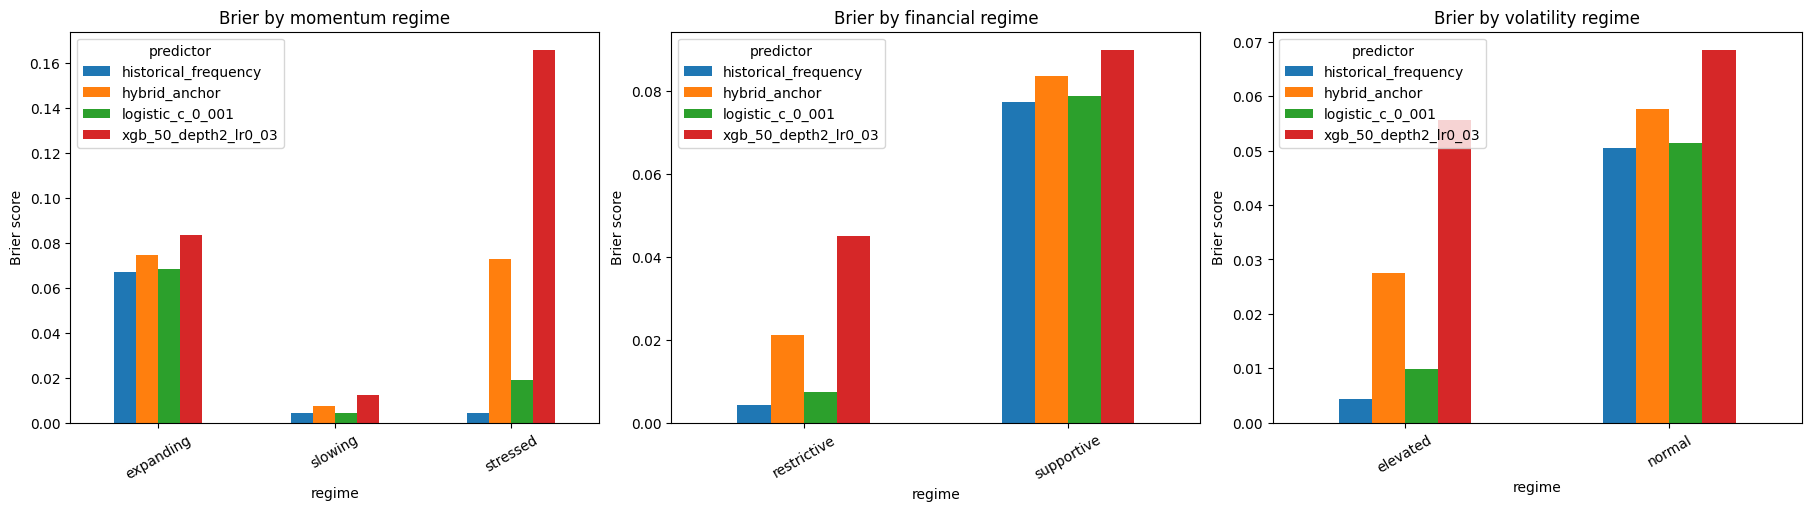

,logistic_weight,mean_brier,delta_vs_logistic,delta_vs_xgboost
0,0.0,0.064321,0.026340,0.000000
1,0.1,0.060536,0.022555,-0.003786
2,0.2,0.057006,0.019025,-0.007315
3,0.3,0.053732,0.015751,-0.010589
4,0.4,0.050714,0.012734,-0.013607
5,0.5,0.047952,0.009972,-0.016369
6,0.6,0.045446,0.007465,-0.018875
7,0.7,0.043196,0.005215,-0.021125
8,0.8,0.041202,0.003221,-0.023119
9,0.9,0.039463,0.001483,-0.024858


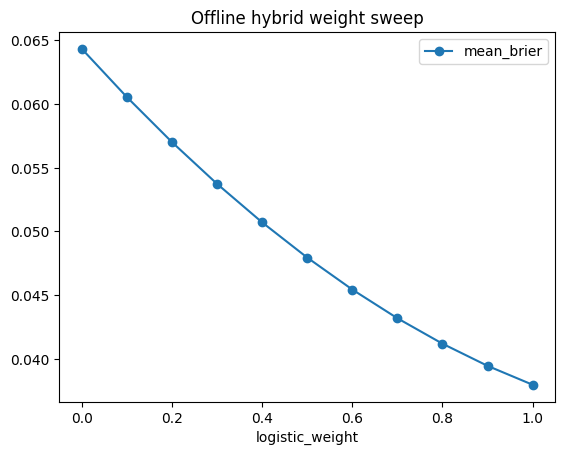

In [21]:
from manufacturing_stress_forecasting.features import build_feature_snapshot
from manufacturing_stress_forecasting.regimes import (
    conditional_brier_table,
    classify_regimes,
    origin_only_threshold,
)


def cutoff_safe_regime_row(origin):
    origin = pd.Timestamp(origin)
    context = service.context(as_of=origin.to_pydatetime())
    feature_frames = {
        series_id: context.get_series(series_id)
        for series_id in FEATURE_SERIES_IDS
    }
    snapshot = build_feature_snapshot(origin, feature_frames)
    if snapshot is None:
        return {
            "as_of": origin,
            "momentum_regime": "unknown",
            "financial_regime": "unknown",
            "volatility_regime": "unknown",
        }
    credit_values = feature_frames["CREDIT_SPREAD"]
    vix_values = feature_frames["VIXCLS"]
    credit_visible = credit_values[pd.to_datetime(credit_values["released_at"]) <= origin]["value"]
    vix_visible = vix_values[pd.to_datetime(vix_values["released_at"]) <= origin]["value"]
    try:
        labels = classify_regimes(
            snapshot,
            historical_credit_median=origin_only_threshold(credit_visible, median=True),
            historical_vix_percentile=origin_only_threshold(vix_visible, percentile=0.66),
        )
    except (KeyError, ValueError):
        labels = {
            "momentum_regime": "unknown",
            "financial_regime": "unknown",
            "volatility_regime": "unknown",
        }
    return {"as_of": origin, **labels}


regime_rows = pd.DataFrame(
    [cutoff_safe_regime_row(origin) for origin in sorted(origin_details["as_of"].unique())]
)
regime_details = origin_details.merge(regime_rows, on="as_of", how="left", validate="many_to_one")
model_wide = (
    regime_details.pivot(index=["as_of", "forecast_date", "outcome", "momentum_regime", "financial_regime", "volatility_regime"], columns="model", values="probability")
    .reset_index()
)
model_wide.columns.name = None
model_columns = [model for model in results if model in model_wide.columns]
expected_keys = set(zip(regime_details["as_of"], regime_details["forecast_date"], strict=True))
actual_keys = set(zip(model_wide["as_of"], model_wide["forecast_date"], strict=True))
assert expected_keys == actual_keys
assert len(model_wide) == len(expected_keys)

print("Regime origin counts:")
for regime_column in ("momentum_regime", "financial_regime", "volatility_regime"):
    counts = model_wide.groupby(regime_column, dropna=False).agg(
        origins=("outcome", "size"),
        stress_events=("outcome", "sum"),
        observed_event_rate=("outcome", "mean"),
    )
    display(counts)

for regime_column in ("momentum_regime", "financial_regime", "volatility_regime"):
    conditional = conditional_brier_table(
        model_wide,
        predictor_columns=model_columns,
        regime_column=regime_column,
        actual_column="outcome",
    )
    conditional["regime_dimension"] = regime_column
    display(conditional[["regime_dimension", "regime", "predictor", "n_origins", "n_events", "event_rate", "mean_probability", "brier", "mean_probability_error"]])

if SHOW_PLOTS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for axis, regime_column in zip(axes, ("momentum_regime", "financial_regime", "volatility_regime"), strict=True):
        conditional = conditional_brier_table(
            model_wide,
            predictor_columns=model_columns,
            regime_column=regime_column,
            actual_column="outcome",
        )
        if conditional.empty:
            axis.set_title(f"{regime_column}: no data")
            continue
        conditional.pivot(index="regime", columns="predictor", values="brier").plot.bar(ax=axis)
        axis.set_title(f"Brier by {regime_column.replace('_', ' ')}")
        axis.set_ylabel("Brier score")
        axis.tick_params(axis="x", rotation=30)
    display(fig)
    plt.close(fig)


weight_rows = []
if {"logistic_c_0_001", "xgb_50_depth2_lr0_03"}.issubset(model_wide.columns):
    for weight in np.linspace(0.0, 1.0, 11):
        probability = weight * model_wide["logistic_c_0_001"] + (1.0 - weight) * model_wide["xgb_50_depth2_lr0_03"]
        weight_rows.append({
            "logistic_weight": round(float(weight), 1),
            "mean_brier": float(np.mean((probability - model_wide["outcome"]) ** 2)),
            "delta_vs_logistic": float(np.mean((probability - model_wide["outcome"]) ** 2) - comparison.loc[comparison["model"] == "logistic_c_0_001", "mean_brier"].iloc[0]),
            "delta_vs_xgboost": float(np.mean((probability - model_wide["outcome"]) ** 2) - comparison.loc[comparison["model"] == "xgb_50_depth2_lr0_03", "mean_brier"].iloc[0]),
        })
    weight_results = pd.DataFrame(weight_rows)
    display(weight_results)
    if SHOW_PLOTS:
        weight_results.plot(x="logistic_weight", y="mean_brier", marker="o", title="Offline hybrid weight sweep")
        plt.show()


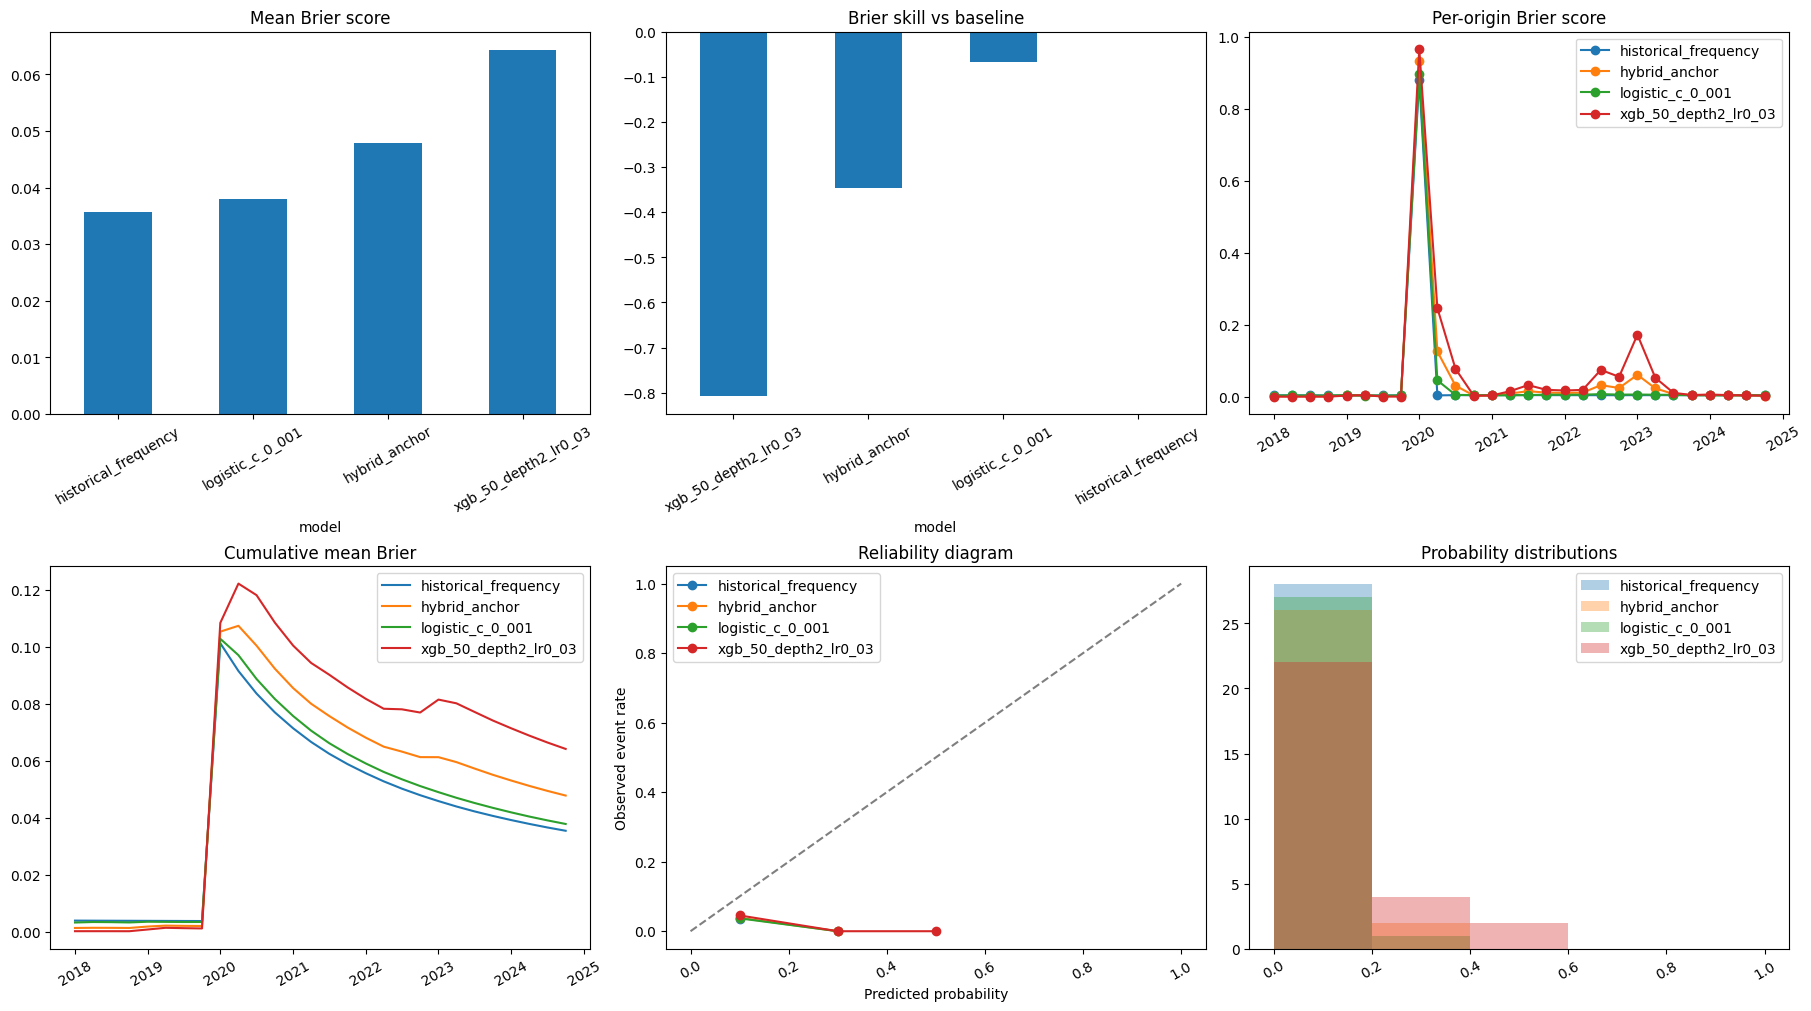

In [22]:
if SHOW_PLOTS:
    plot_data = origin_details.copy()
    plot_data['as_of'] = pd.to_datetime(plot_data['as_of'])
    plot_data['forecast_date'] = pd.to_datetime(plot_data['forecast_date'])
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    comparison.sort_values('mean_brier').plot.bar(x='model', y='mean_brier', ax=axes[0, 0], legend=False, title='Mean Brier score')
    comparison.sort_values('brier_skill').plot.bar(x='model', y='brier_skill', ax=axes[0, 1], legend=False, title='Brier skill vs baseline')

    for model, group in plot_data.groupby('model'):
        axes[0, 2].plot(group['as_of'], group['brier'], marker='o', label=model)
    axes[0, 2].set_title('Per-origin Brier score')
    axes[0, 2].legend()

    for model, group in plot_data.groupby('model'):
        ordered = group.sort_values('as_of')
        axes[1, 0].plot(ordered['as_of'], ordered['brier'].expanding().mean(), label=model)
    axes[1, 0].set_title('Cumulative mean Brier')
    axes[1, 0].legend()

    bins = np.linspace(0, 1, 6)
    centers = (bins[:-1] + bins[1:]) / 2
    for model, group in plot_data.groupby('model'):
        bucketed = group.assign(probability_bin=pd.cut(group['probability'], bins=bins, labels=False, include_lowest=True))
        calibration = bucketed.dropna(subset=['probability_bin']).groupby('probability_bin', observed=True).agg(
            predicted=('probability', 'mean'), observed=('outcome', 'mean')
        )
        axes[1, 1].plot(calibration.index.map(lambda index: centers[int(index)]), calibration['observed'], marker='o', label=model)
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1, 1].set_title('Reliability diagram')
    axes[1, 1].set_xlabel('Predicted probability')
    axes[1, 1].set_ylabel('Observed event rate')
    axes[1, 1].legend()

    for model, group in plot_data.groupby('model'):
        axes[1, 2].hist(group['probability'], bins=bins, alpha=0.35, label=model)
    axes[1, 2].set_title('Probability distributions')
    axes[1, 2].legend()

    for axis in axes.flat:
        axis.tick_params(axis='x', rotation=30)
    display(fig)
    plt.close(fig)

## Interpretation

A lower Brier score indicates better probabilistic accuracy. Positive Brier skill means improvement over historical frequency. A reliability curve near the diagonal indicates calibration. Large differences between per-origin and cumulative plots indicate regime sensitivity.

The hybrid anchor is derived from logistic and XGBoost and is included as a baseline. When enabled, `hybrid_agent_adjusted` reports the stateless hybrid agent and `adaptive_agent` reports the stateful adaptive agent. Both use Python-bounded adjustments; their anchors, agent proposals, applied adjustments, and evidence remain available as metadata.